In [24]:

import sys
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize
import numpy as np
import matplotlib.pyplot as plt
import mpl_scatter_density


data = np.load("../../../_recordings/2024-06-27--11-52-35_split-correlators/archive.npz")



results = {}

for experiment in data.keys():
    experiment_parameters = data[experiment]["reboot_seed"]["experiment_parameters"][0]
    shape = experiment_parameters["shape"]

    if shape[0] in results:
        results[shape[0]].append(data[experiment])
    else:
        results[shape[0]] = [data[experiment]]

z_order = 7
roots_of_unity = np.array([[np.cos(2 * np.pi * i / z_order),
                                np.sin(2 * np.pi * i / z_order)] for i in range(z_order)])



lattice_sizes = []

result_keys = list(results.keys())
result_keys.sort()


time_series = {}
tin_data = {}
pp_correlators = {}
average_plaquettes = {}
pp_corr_differences = {}
average_plaquette_integer = {}
lateral_correlators = {}
longitudinal_correlators = {}

for shape in result_keys:
    results[shape].sort(key=lambda x: x["reboot_seed"]["experiment_parameters"]["beta"])

    print(shape)
    for res in results[shape]:
        print(res.dtype)


    results[shape] = np.array(results[shape])

    # 

    rec_shape = results[shape]["ploop_corr_recordings"]["polyakov_loops"].shape

    _,_,number_rec, x_dim, y_dim, z_dim = rec_shape


    loops = results[shape]["ploop_corr_recordings"]["polyakov_loops"]
    loops = roots_of_unity[loops]

    # Tin Data
    temp = loops.sum(axis=(3,4,5))
    tin_snapshot = np.linalg.norm(temp, axis=-1)  
    tin_snapshot = tin_snapshot.sum(axis=(1,2))/(number_rec*x_dim*y_dim*z_dim)
    tin_data[x_dim]= tin_snapshot

    # Time series
    time_serie = loops.sum(axis=(3,4,5)).squeeze(axis=1)/(x_dim*y_dim*z_dim)
    time_series[x_dim] = time_serie

    betas = results[shape]["reboot_seed"]["experiment_parameters"]["beta"].squeeze()

    lattice_sizes.append(x_dim)

    pp_correlators[x_dim] = results[shape]["ploop_corr_recordings"]["pp_correlators"]
    average_plaquettes[x_dim] = results[shape]["ploop_corr_recordings"]["average_plaquette"]
    pp_corr_differences[x_dim] = results[shape]["ploop_corr_recordings"]["pp_correlators_differences"]
    average_plaquette_integer[x_dim] = results[shape]["ploop_corr_recordings"]["average_plaquette_integer"]
    lateral_correlators[x_dim] = results[shape]["ploop_corr_recordings"]["lateral_correlators"]
    longitudinal_correlators[x_dim] = results[shape]["ploop_corr_recordings"]["longitudinal_correlators"]

 


# save the data
np.savez("temp/treated_data_split_correlators", time_series=time_series, tin_data=tin_data, betas=betas, lattice_sizes=lattice_sizes, pp_correlators=pp_correlators, average_plaquettes=average_plaquettes, pp_corr_differences=pp_corr_differences, average_plaquette_integer=average_plaquette_integer, lateral_correlators=lateral_correlators, longitudinal_correlators=longitudinal_correlators)
    



6
[('reboot_seed', [('last_state', [('edges', 'u1', (5184,)), ('rng_gen', [('rng_gen_wrapper', 'u1', (16,))]), ('performed_updates', '<u8'), ('accepted_updates', '<u8')]), ('experiment_parameters', [('shape', '<u4', (4,)), ('z_order', '<u4'), ('beta', '<f4'), ('lambda', '<f4'), ('rng_seed', '<u8')])]), ('run_info', [('recordings', '<u4'), ('recording_skip', '<u4'), ('recordings_until_backup', '<u4'), ('backup_number', '<u4'), ('recording_time', '<i8'), ('run_id', '<u4')]), ('ploop_corr_recordings', [('polyakov_loops', 'u1', (100000, 6, 6, 6)), ('polyakov_loop_correlators', '<f4', (100000, 7, 2)), ('pp_correlators', '<f4', (100000, 7, 2)), ('average_plaquette', '<f4', (100000, 2)), ('pp_correlators_differences', '<u8', (100000, 7, 7)), ('average_plaquette_integer', '<u8', (100000, 7)), ('lateral_correlators', '<u8', (100000, 7, 7)), ('longitudinal_correlators', '<u8', (100000, 7, 7))])]
[('reboot_seed', [('last_state', [('edges', 'u1', (5184,)), ('rng_gen', [('rng_gen_wrapper', 'u1', (1

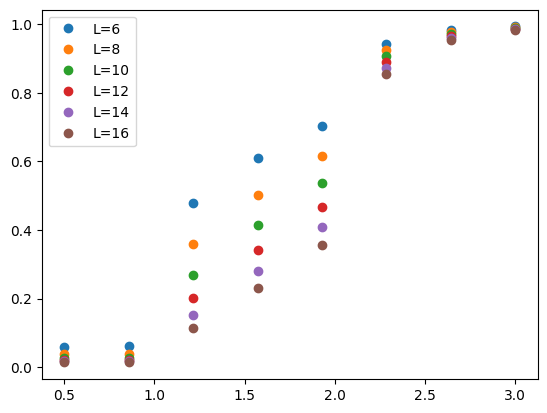

In [5]:
data = np.load("temp/treated_data_split_correlators.npz", allow_pickle=True)

tin_data = data["tin_data"].item()
betas = data["betas"]

fig, ax = plt.subplots()

for key in tin_data.keys():
    ax.plot(betas, tin_data[key], 'o', label=f"L={key}")

ax.legend()
plt.show()


6 (8, 100000, 2)
8 (8, 100000, 2)
10 (8, 59000, 2)
12 (8, 27000, 2)
14 (8, 14000, 2)
16 (8, 7000, 2)


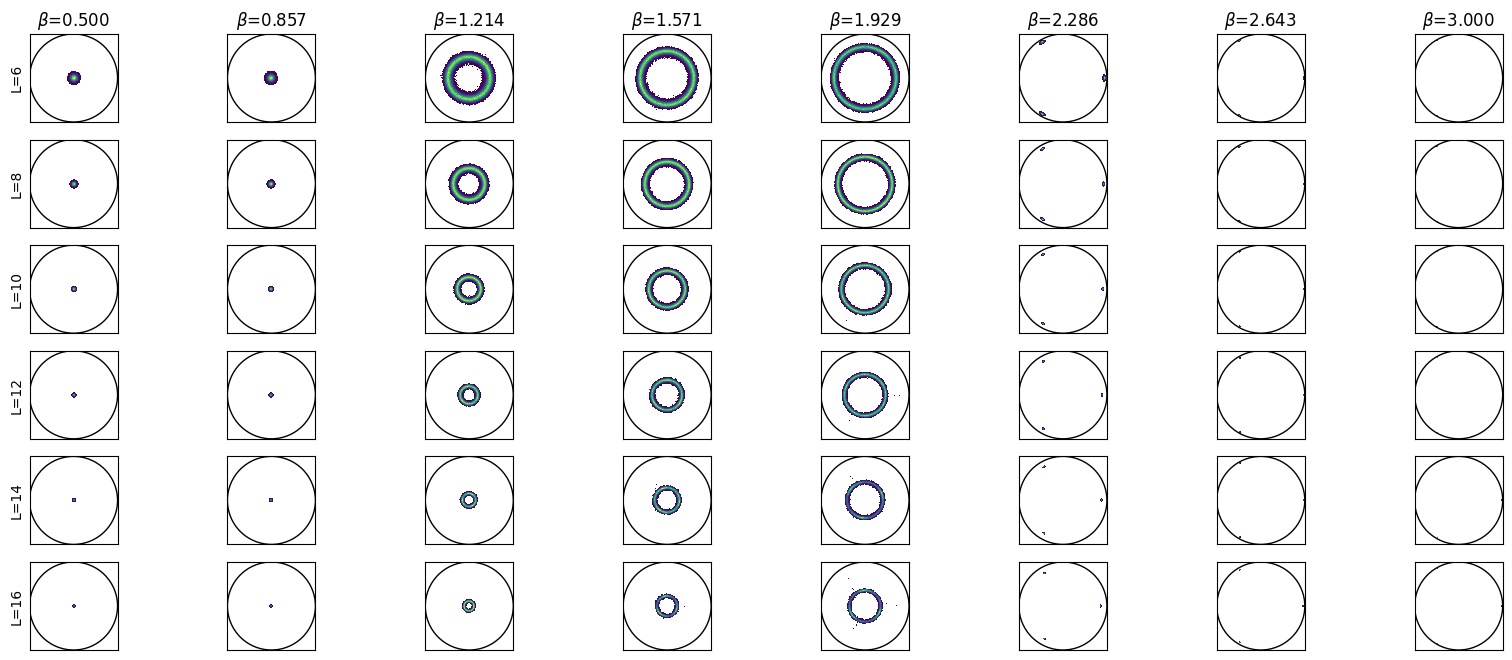

In [7]:

data = np.load("temp/treated_data_split_correlators.npz", allow_pickle=True)

time_series = data["time_series"].item()

betas = data["betas"]


for key in time_series.keys():
    print(key, time_series[key].shape)

# Give number of keys in the dictionary
num_lattice_sizes = len(time_series.keys())


rows = num_lattice_sizes
columns = len(betas)


fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(rows, columns)

axes = []

white_viridis = LinearSegmentedColormap.from_list('white_viridis', [
    (0, '#ffffff'),
    (1e-20, '#440053'),
    (0.2, '#404388'),
    (0.4, '#2a788e'),
    (0.6, '#21a784'),
    (0.8, '#78d151'),
    (1, '#fde624'),
], N=256)

# for i in range(rows):
for (i, key) in enumerate(time_series.keys()):
    for j in range(columns):
        time_serie = time_series[key][j]
        time_serie_rotated = time_serie.copy()
        rotation_matrix = np.array([[np.cos(2 * np.pi / 3), -np.sin(2 * np.pi / 3)], [
                                    np.sin(2 * np.pi / 3), np.cos(2 * np.pi / 3)]])

        time_serie_rotated = np.dot(time_serie, rotation_matrix)
        time_serie = np.concatenate([time_serie, time_serie_rotated])

        time_serie_rotated = np.dot(time_serie_rotated, rotation_matrix)
        time_serie = np.concatenate([time_serie, time_serie_rotated])

        x = time_serie[:, 0]
        y = time_serie[:, 1]

        radius = 1

        axes.append(fig.add_subplot(
            gs[i, j], projection='scatter_density'))

        axes[-1].set_xlim(-radius, radius)
        axes[-1].set_ylim(-radius, radius)

        axes[-1].scatter_density(x, y, cmap=white_viridis, dpi=200)

        axes[-1].set_xlim(-radius, radius)
        axes[-1].set_ylim(-radius, radius)

        axes[-1].set_aspect('equal', 'box')
        axes[-1].set_xticks([])
        axes[-1].set_yticks([])
        # axes[-1].set_title(f"{index}")
        circle = plt.Circle((0, 0), 1, color='black', fill=False)
        axes[-1].add_artist(circle)


for i in range(columns):
    axes[i].set_title(r"$\beta$={:.3f}".format(
        betas[i]))

# Add title to rows
for i in range(rows):
    axes[i*columns].set_ylabel(f"L={lattice_sizes[i]}")

plt.show()


(8, 1, 100000, 7, 2)
(8, 1, 100000, 9, 2)
(8, 1, 59000, 11, 2)
(8, 1, 27000, 13, 2)
(8, 1, 14000, 15, 2)
(8, 1, 7000, 17, 2)


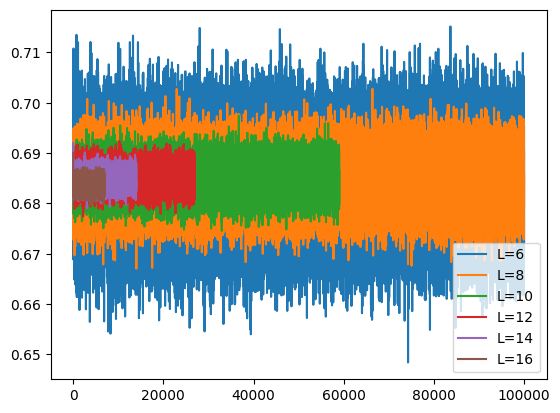

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

data = np.load("temp/treated_data_split_correlators.npz", allow_pickle=True)
pp_correlators = data["pp_correlators"].item()

fig = plt.figure()

which_beta = 3

# Use colormap viridis to color the lines according to the lattice size
cmap = plt.get_cmap('viridis')
norm = Normalize(vmin=6, vmax=16)



for key in pp_correlators.keys():
    print(pp_correlators[key].shape)

    pp_correlator = pp_correlators[key][which_beta,:,...].squeeze(axis=0)

    lattice_size = 2
    time_series = pp_correlator

    time_series = time_series[:,lattice_size,0]

    time_series = time_series[1:]

    xs = np.arange(len(time_series))

    color = cmap(norm(key))

    plt.plot(xs[1:], time_series[1:], '-', label=f"L={key}")

plt.legend()
plt.show()


[0.5        0.85714287 1.2142857  1.5714285  1.9285715  2.2857144
 2.642857   3.        ]
1.2689488490091883e-05
2.0177344536076447e-05
0.00013046099208913198
0.000304722604589025
0.00039352563319727807
0.000435162981351378


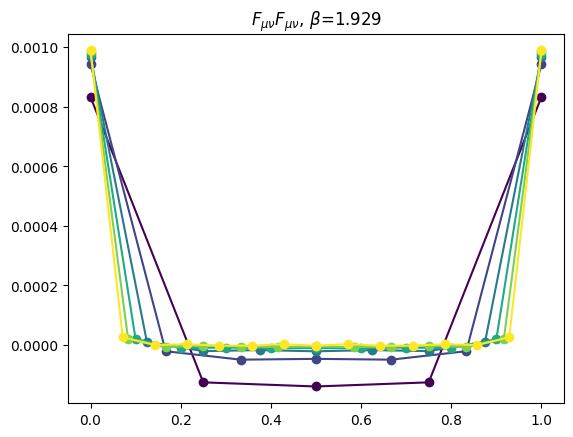

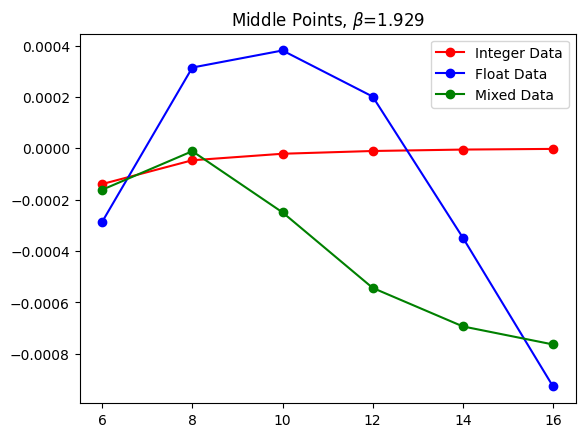

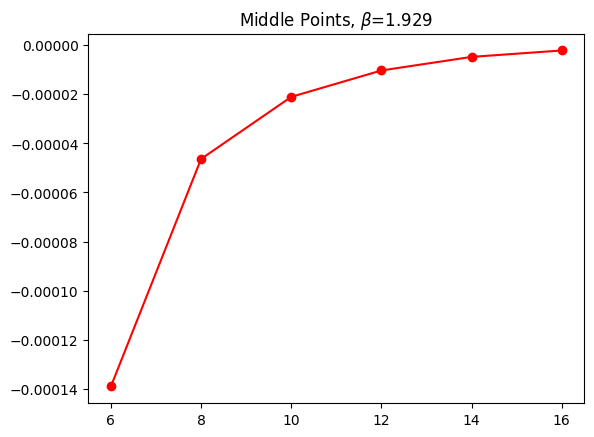

In [28]:
import sys
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize
import numpy as np
import matplotlib.pyplot as plt
import mpl_scatter_density


data = np.load("temp/treated_data_split_correlators.npz", allow_pickle=True)
pp_correlators = data["pp_correlators"].item()
average_plaquettes = data["average_plaquettes"].item()
betas = data["betas"]
pp_corr_differences = data["pp_corr_differences"].item()
average_plaquette_integer = data["average_plaquette_integer"].item()

print(betas)


fig = plt.figure()

min_lattice_size = np.min(list(pp_correlators.keys()))
max_lattice_size = np.max(list(pp_correlators.keys()))

# Use colormap viridis to color the lines according to the lattice size
cmap = plt.get_cmap('viridis')
norm = Normalize(vmin=min_lattice_size, vmax=max_lattice_size)


which_beta = 4

middle_points = []
middle_points_float = []
middle_points_mixed = []

keys = list(pp_correlators.keys())

for (i,key) in enumerate(pp_correlators.keys()):

    # if key != 6:
    #     continue

    for beta in range(which_beta, (which_beta+1)):
        pp_correlator = pp_correlators[key][beta,:,...].squeeze(axis=0)
        average_plaquette = average_plaquettes[key][beta,:,...].squeeze(axis=0)

        color = cmap(norm(i))

        thermalise = 0

        pp_correlator_mean = pp_correlator[thermalise:].mean(axis=0)[:]
        average_plaquette_mean = average_plaquette[thermalise:].mean(axis=0)


        pp_correlator_mean = pp_correlator_mean[:,0]
        average_plaquette_mean = average_plaquette_mean[0]

    
    

        cutoff = 1
        if cutoff > 0:
            pp_correlator_mean = pp_correlator_mean[cutoff:-cutoff]
        else: 
            pp_correlator_mean = pp_correlator_mean




        pp_correlator_mean = pp_correlator_mean - average_plaquette_mean**2

        Ls = np.arange(len(pp_correlator_mean))
        max_L = np.max(Ls)
        Ls = Ls / max_L

        

        variance = pp_correlator.var(axis=0)[:,0]
        variance = variance[cutoff:-cutoff]
        std = np.sqrt(variance/len(pp_correlator))


        differences = pp_corr_differences[key][beta,...].squeeze()
        differences = differences.sum(axis=0)
        exponential_map = np.array([[np.cos(2*np.pi*i/7), np.sin(2*np.pi*i/7)] for i in range(7)])


        distance_correlators = []
        for i in range(0, len(differences)):
            total_correlators = sum(differences[i,:])
            corr = np.array([0.0,0.0])
            for j in range(0, len(differences[i])):
                corr += differences[i,j]*exponential_map[j]
            distance_correlators.append(corr/total_correlators)

        


        average_p_integer = average_plaquette_integer[key][beta,...].squeeze()
        average_p_integer = average_p_integer.sum(axis=0)
        total_average_integer = average_p_integer.sum(axis=0)

        res_average_p_integer = np.array([0.0,0.0])
        for j in range(0, len(average_p_integer)):
            res_average_p_integer += average_p_integer[j]*exponential_map[j]
        
        res_average_p_integer = res_average_p_integer/total_average_integer

        print(abs(res_average_p_integer[0] - average_plaquette_mean))

        integer_correlators = np.array(distance_correlators)[:,0][cutoff:-cutoff] - res_average_p_integer[0]**2      
        

        mixed_precision = np.array(distance_correlators)[:,0][cutoff:-cutoff] - average_plaquette_mean**2
        # 

        color = cmap(norm(key))
        plt.plot(Ls, integer_correlators, '-o', color=color)

        middle_points.append(integer_correlators[len(integer_correlators)//2])

        # plt.plot(0.5, integer_correlators[len(integer_correlators)//2], 'o', color='red')

        # plt.plot(Ls, mixed_precision, '-o', color='green')
        # plt.plot(Ls, pp_correlator_mean, '-o', color='blue')
        middle_points_float.append(pp_correlator_mean[len(pp_correlator_mean)//2])
        middle_points_mixed.append(mixed_precision[len(mixed_precision)//2])
        


    

import matplotlib.patches as mpatches

beta = betas[which_beta]


red_patch = mpatches.Patch(color='red', label='Integer Data')
green_patch = mpatches.Patch(color='green', label='Mixed Data')
blue_patch = mpatches.Patch(color='blue', label='Float Data')
# plt.legend(handles=[red_patch, green_patch, blue_patch])

plt.title(r"$F_{{\mu\nu}}F_{{\mu\nu}}$, $\beta$={:.3f}".format(beta))


plt.show()

lattice_sizes = keys
min_lattice_size = np.min(lattice_sizes)
max_lattice_size = np.max(lattice_sizes)

lattice_sizes = range(min_lattice_size, max_lattice_size+1, 2)

fig = plt.figure()
plt.plot(lattice_sizes, middle_points, '-o', color='red', label='Integer Data')
plt.plot(lattice_sizes, middle_points_float, '-o', color='blue',  label='Float Data')
plt.plot(lattice_sizes, middle_points_mixed, '-o', color='green', label='Mixed Data')

plt.title(r"Middle Points, $\beta$={:.3f}".format(beta))
plt.legend()

plt.show()

fig = plt.figure()
plt.plot(lattice_sizes, middle_points, '-o', color='red')
plt.title(r"Middle Points, $\beta$={:.3f}".format(beta))
plt.show()


Fitted Parameters:
a = -0.20851377736962767
b = 1.0
c = 1.0


/var/folders/85/yh7sv5kx12nfh8mkhfkgjrt40000gn/T/ipykernel_81183/759891578.py:28: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(power_law, x, y)


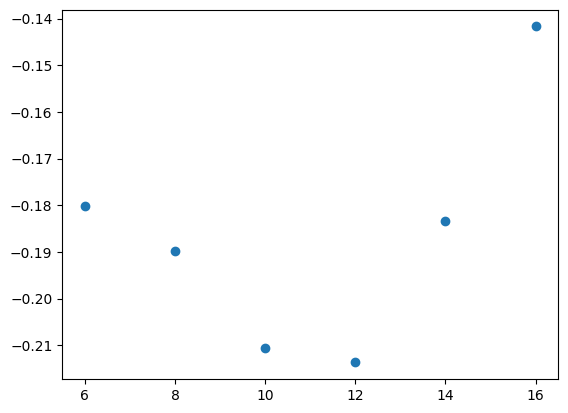

In [138]:
# Fit the data with a power law
from scipy.optimize import curve_fit
import numpy as np
from scipy.optimize import curve_fit

# Define the power law function
def power_law(x, a, b, c):
    return a * 1/(x**4) #+ b * 1/(x**6) + c * 1/(x**8)


old_x = np.array(lattice_sizes)
old_y = middle_points

# Define your x and y data
cutoff = 2

if cutoff == 0:
    x = np.array(lattice_sizes)
    y = middle_points

else:
    x = np.array(lattice_sizes)[cutoff:]
    y = middle_points[cutoff:]



# Perform the power law fit
params, _ = curve_fit(power_law, x, y)

# Extract the fitted parameters
a_fit, b_fit, c_fit = params

# Print the fitted parameters
print("Fitted Parameters:")
print("a =", a_fit)
print("b =", b_fit)
print("c =", c_fit)


# Plot the data and the fitted curve
import matplotlib.pyplot as plt

# Define the x range for the fitted curve

x_fit = np.linspace(6, max(x), 100)

old_y = old_y * (old_x**4)


# Plot the data
plt.plot(old_x, old_y, 'o', zorder = 10)

# Plot the fitted curve
# plt.plot(x_fit, power_law(x_fit, a_fit, b_fit, c_fit), label="Fitted Curve")




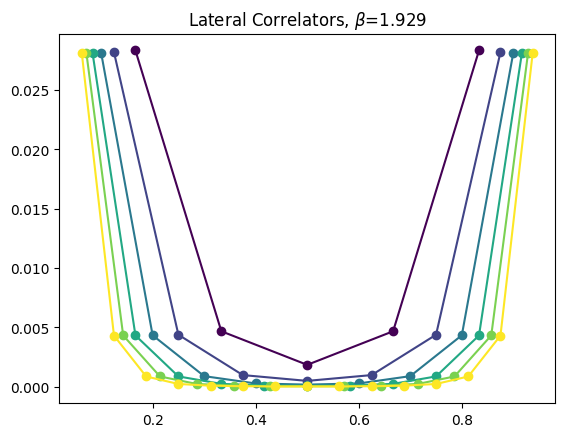

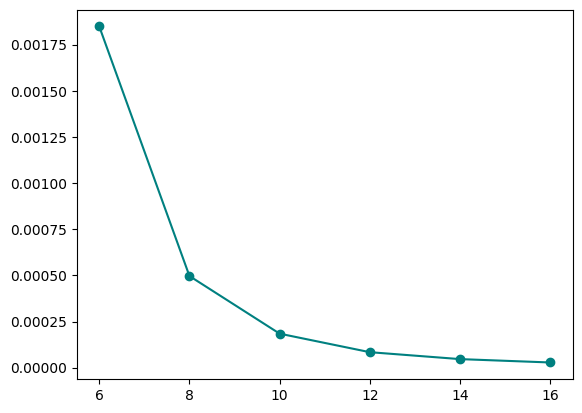

In [29]:
data = np.load("temp/treated_data_split_correlators.npz", allow_pickle=True)

lateral_correlators_dict = data["lateral_correlators"].item()
average_plaquette_integer = data["average_plaquette_integer"].item()


min_lattice_size = np.min(list(lateral_correlators_dict.keys()))
max_lattice_size = np.max(list(lateral_correlators_dict.keys()))

cmap = plt.get_cmap('viridis')
norm = Normalize(vmin=min_lattice_size, vmax=max_lattice_size)


which_beta = 4
ZORDER = 7
cutoff = 1

fig = plt.figure()


lateral_midpoints = []

for key in lateral_correlators_dict.keys():

    lateral_correlator = lateral_correlators_dict[key][which_beta,:,...].squeeze(axis=0)
    lateral_correlator = lateral_correlator.sum(axis=0)
    exponential_map = np.array([[np.cos(2*np.pi*i/ZORDER), np.sin(2*np.pi*i/ZORDER)] for i in range(ZORDER)])

    lateral_correlators = []
    for i in range(0, len(lateral_correlator)):
        total_correlators = sum(lateral_correlator[i,:])
        corr = np.array([0.0,0.0])
        for j in range(0, len(lateral_correlator[i])):
            corr += lateral_correlator[i,j]*exponential_map[j]
        lateral_correlators.append(corr/total_correlators)

    lateral_correlators = np.array(lateral_correlators)[:,0]

    # Calculate the average plaquette
    average_p_integer = average_plaquette_integer[key][which_beta,...].squeeze()
    average_p_integer = average_p_integer.sum(axis=0)
    total_average_integer = average_p_integer.sum(axis=0)

    res_average_p_integer = np.array([0.0,0.0])
    for j in range(0, len(average_p_integer)):
        res_average_p_integer += average_p_integer[j]*exponential_map[j]

    res_average_p_integer = res_average_p_integer/total_average_integer

    # Subtract vaccum expectation value
    lateral_correlators = lateral_correlators - res_average_p_integer[0]**2

    lateral_midpoints.append(lateral_correlators[len(lateral_correlators)//2])


    Ls = np.linspace(0, 1, len(lateral_correlators))
    color = cmap(norm(key))

    plt.plot(Ls[cutoff:-cutoff], lateral_correlators[cutoff:-cutoff], '-o', color=color)

plt.title(r"Lateral Correlators, $\beta$={:.3f}".format(betas[which_beta]))
plt.show()

fig = plt.figure()

lattice_sizes = range(min_lattice_size, max_lattice_size+1, 2)

plt.plot(lattice_sizes, lateral_midpoints, '-o', color='teal')






6, [769244415   4175683      2058        66        66      2087   4175625]
0.005428291604821076
8, [2431177728   13203849       6959        255        264       6809
   13204136]
0.00543105049373009
10, [3501935648   19021943       9778        332        333       9537
   19022429]
0.005431836821691362
12, [3323141502   18035701       9199        315        307       9126
   18035850]
0.005427304551775899
14, [3192283996   17321136       8606        331        322       8759
   17320850]
0.005425938300509526
16, [2722933252   14781469       7627        240        243       7531
   14781638]
0.005428509490323709


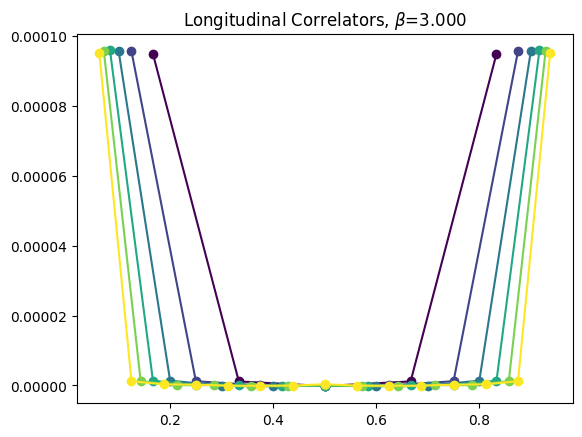

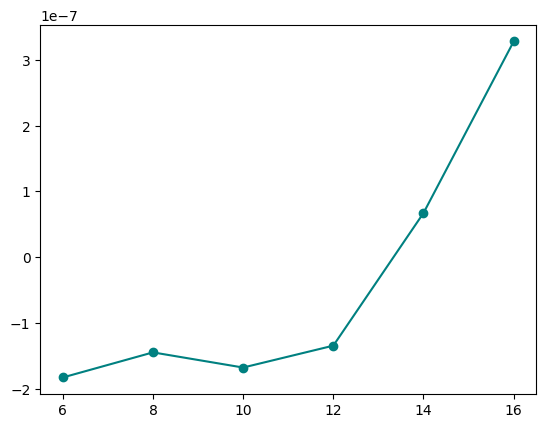

In [141]:

import sys
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize
import numpy as np
import matplotlib.pyplot as plt
import mpl_scatter_density


data = np.load("temp/treated_data_split_correlators.npz", allow_pickle=True)
betas = data["betas"]

longitudinal_correlators_dict = data["longitudinal_correlators"].item()
average_plaquette_integer = data["average_plaquette_integer"].item()


min_lattice_size = np.min(list(longitudinal_correlators_dict.keys()))
max_lattice_size = np.max(list(longitudinal_correlators_dict.keys()))

cmap = plt.get_cmap('viridis')
norm = Normalize(vmin=min_lattice_size, vmax=max_lattice_size)


which_beta = 7
ZORDER = 7
cutoff = 1

longitudinal_midpoints = []


for key in longitudinal_correlators_dict.keys():

    longitudinal_correlator = longitudinal_correlators_dict[key][which_beta,:,...].squeeze(axis=0)
    longitudinal_correlator = longitudinal_correlator.sum(axis=0)
    exponential_map = np.array([[np.cos(2*np.pi*i/ZORDER), np.sin(2*np.pi*i/ZORDER)] for i in range(ZORDER)])

    longitudinal_correlators = []
    for i in range(0, len(longitudinal_correlator)):
        total_correlators = sum(longitudinal_correlator[i,:])
        corr = np.array([0.0,0.0])
        for j in range(0, len(longitudinal_correlator[i])):
            corr += longitudinal_correlator[i,j]*exponential_map[j]
        longitudinal_correlators.append(corr/total_correlators)

    longitudinal_correlators = np.array(longitudinal_correlators)[:,0]

    # Calculate the average plaquette
    average_p_integer = average_plaquette_integer[key][which_beta,...].squeeze()
    average_p_integer = average_p_integer.sum(axis=0)
    total_average_integer = average_p_integer.sum(axis=0)

    res_average_p_integer = np.array([0.0,0.0])
    for j in range(0, len(average_p_integer)):
        res_average_p_integer += average_p_integer[j]*exponential_map[j]

    res_average_p_integer = res_average_p_integer/total_average_integer
    print(f"{key}, {average_p_integer}")

    print(average_p_integer[1]/average_p_integer[0])

    # Subtract vaccum expectation value
    longitudinal_correlators = longitudinal_correlators - res_average_p_integer[0]**2


    Ls = np.linspace(0, 1, len(longitudinal_correlators))
    color = cmap(norm(key))

    longitudinal_midpoints.append(longitudinal_correlators[len(longitudinal_correlators)//2])

    plt.plot(Ls[cutoff:-cutoff], longitudinal_correlators[cutoff:-cutoff], '-o', color=color)

plt.title(r"Longitudinal Correlators, $\beta$={:.3f}".format(betas[which_beta]))

plt.show()

fig = plt.figure()

lattice_sizes = range(min_lattice_size, max_lattice_size+1, 2)

plt.plot(lattice_sizes, longitudinal_midpoints, '-o', color='teal')




Fitted Parameters:
a = 1.4294297657198674
b = 757.7733458241942


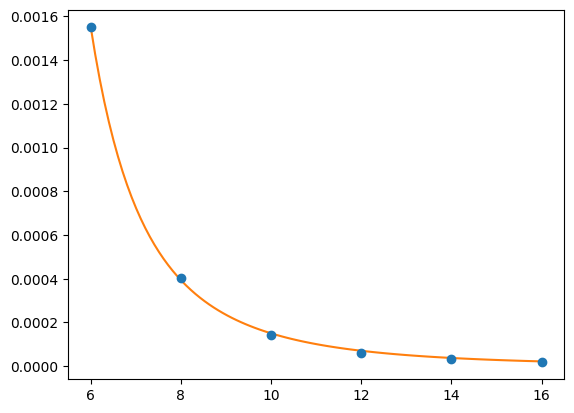

In [117]:
# Fit the data with a power law
from scipy.optimize import curve_fit
import numpy as np
from scipy.optimize import curve_fit

# Define the power law function
def power_law(x, a, b):
    return a * 1/(x**4) + b * 1/(x**8) #+ c * 1/(x**8)



# Define your x and y data
cutoff = 0

if cutoff == 0:
    x = np.array(lattice_sizes)
    y = longitudinal_midpoints

else:
    x = np.array(lattice_sizes)[cutoff:]
    y = longitudinal_midpoints[cutoff:]



# Perform the power law fit
params, _ = curve_fit(power_law, x, y)

# Extract the fitted parameters
a_fit, b_fit = params

# Print the fitted parameters
print("Fitted Parameters:")
print("a =", a_fit)
print("b =", b_fit)
# print("c =", c_fit)


# Plot the data and the fitted curve
import matplotlib.pyplot as plt

# Define the x range for the fitted curve

x_fit = np.linspace(min(x), max(x), 100)

# Plot the data
plt.plot(x, y, 'o', zorder = 10)

# Plot the fitted curve
plt.plot(x_fit, power_law(x_fit, a_fit, b_fit), label="Fitted Curve")


